In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dt = pd.read_csv("smartcart_customers.csv")

In [3]:
dt.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
dt.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [5]:
dt.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Pre-processing

In [6]:
# Handle missing val
dt["Income"] = dt["Income"].fillna(dt["Income"].median())

In [7]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
dt.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [9]:
dt.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [10]:
# 1. Every customer's age
dt['Age'] = 2026 - dt['Year_Birth']

In [11]:
dt.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [12]:
# 2. Every customer's tenure days

# *First change the date time format, because want 'd-m-y' and pandas has 'm-d-y'
dt['Dt_Customer'] = pd.to_datetime(dt['Dt_Customer'], dayfirst=True)

# *Find the last day of joining of customer
reference_date = dt['Dt_Customer'].max()

# *Calculate tenure of every customer
dt['Customer_tenure_days'] = (reference_date - dt['Dt_Customer']).dt.days

In [13]:
dt.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [14]:
# Every customer's total spending 

dt['Customer_total_spend'] = dt['MntWines'] + dt['MntFruits'] + dt['MntMeatProducts'] + dt['MntFishProducts'] + dt['MntSweetProducts'] + dt['MntGoldProds']

In [15]:
dt.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [16]:
# Every customer's total children

dt['Children'] = dt['Kidhome'] + dt['Teenhome']

In [17]:
dt.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [18]:
# Classify Education into three categories
dt['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
dt['Education'] = dt['Education'].replace({
                                           'Basic':'UnderGrade', '2n Cycle':'UnderGrade',
                                           'Graduation':'Grade',
                                           'PhD':'MasterGrade', 'Master':'MasterGrade'
})

In [20]:
dt['Education'].value_counts()

Education
Grade          1127
MasterGrade     856
UnderGrade      257
Name: count, dtype: int64

In [21]:
# Classify living status into two categories
dt['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
dt['Marital_Status'] = dt['Marital_Status'].replace({
                                                     'Married':'Living_with', 'Together':'Living_with',
                                                     'Single':'Living_alone', 'Divorced':'Living_alone', 'Widow':'Living_alone', 
                                                     'Alone':'Living_alone', 'Absurd':'Living_alone', 'YOLO':'Living_alone'
})

In [23]:
dt['Marital_Status'].value_counts()

Marital_Status
Living_with     1444
Living_alone     796
Name: count, dtype: int64

In [24]:
dt.shape

(2240, 26)

In [25]:
dt.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days',
       'Customer_total_spend', 'Children'],
      dtype='object')

In [26]:
# At last, drop unnecessary columns
unnecessary_cols = ['ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Dt_Customer', 
                    'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

dt_cleaned = dt.drop(columns=unnecessary_cols)

In [27]:
dt_cleaned.shape

(2240, 15)

In [28]:
dt_cleaned.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children
0,Grade,Living_alone,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,Grade,Living_alone,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,Grade,Living_with,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,Grade,Living_with,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,MasterGrade,Living_with,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


# Detect & Remove Outliers

In [29]:
dt_cleaned.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_tenure_days', 'Customer_total_spend', 'Children'],
      dtype='object')

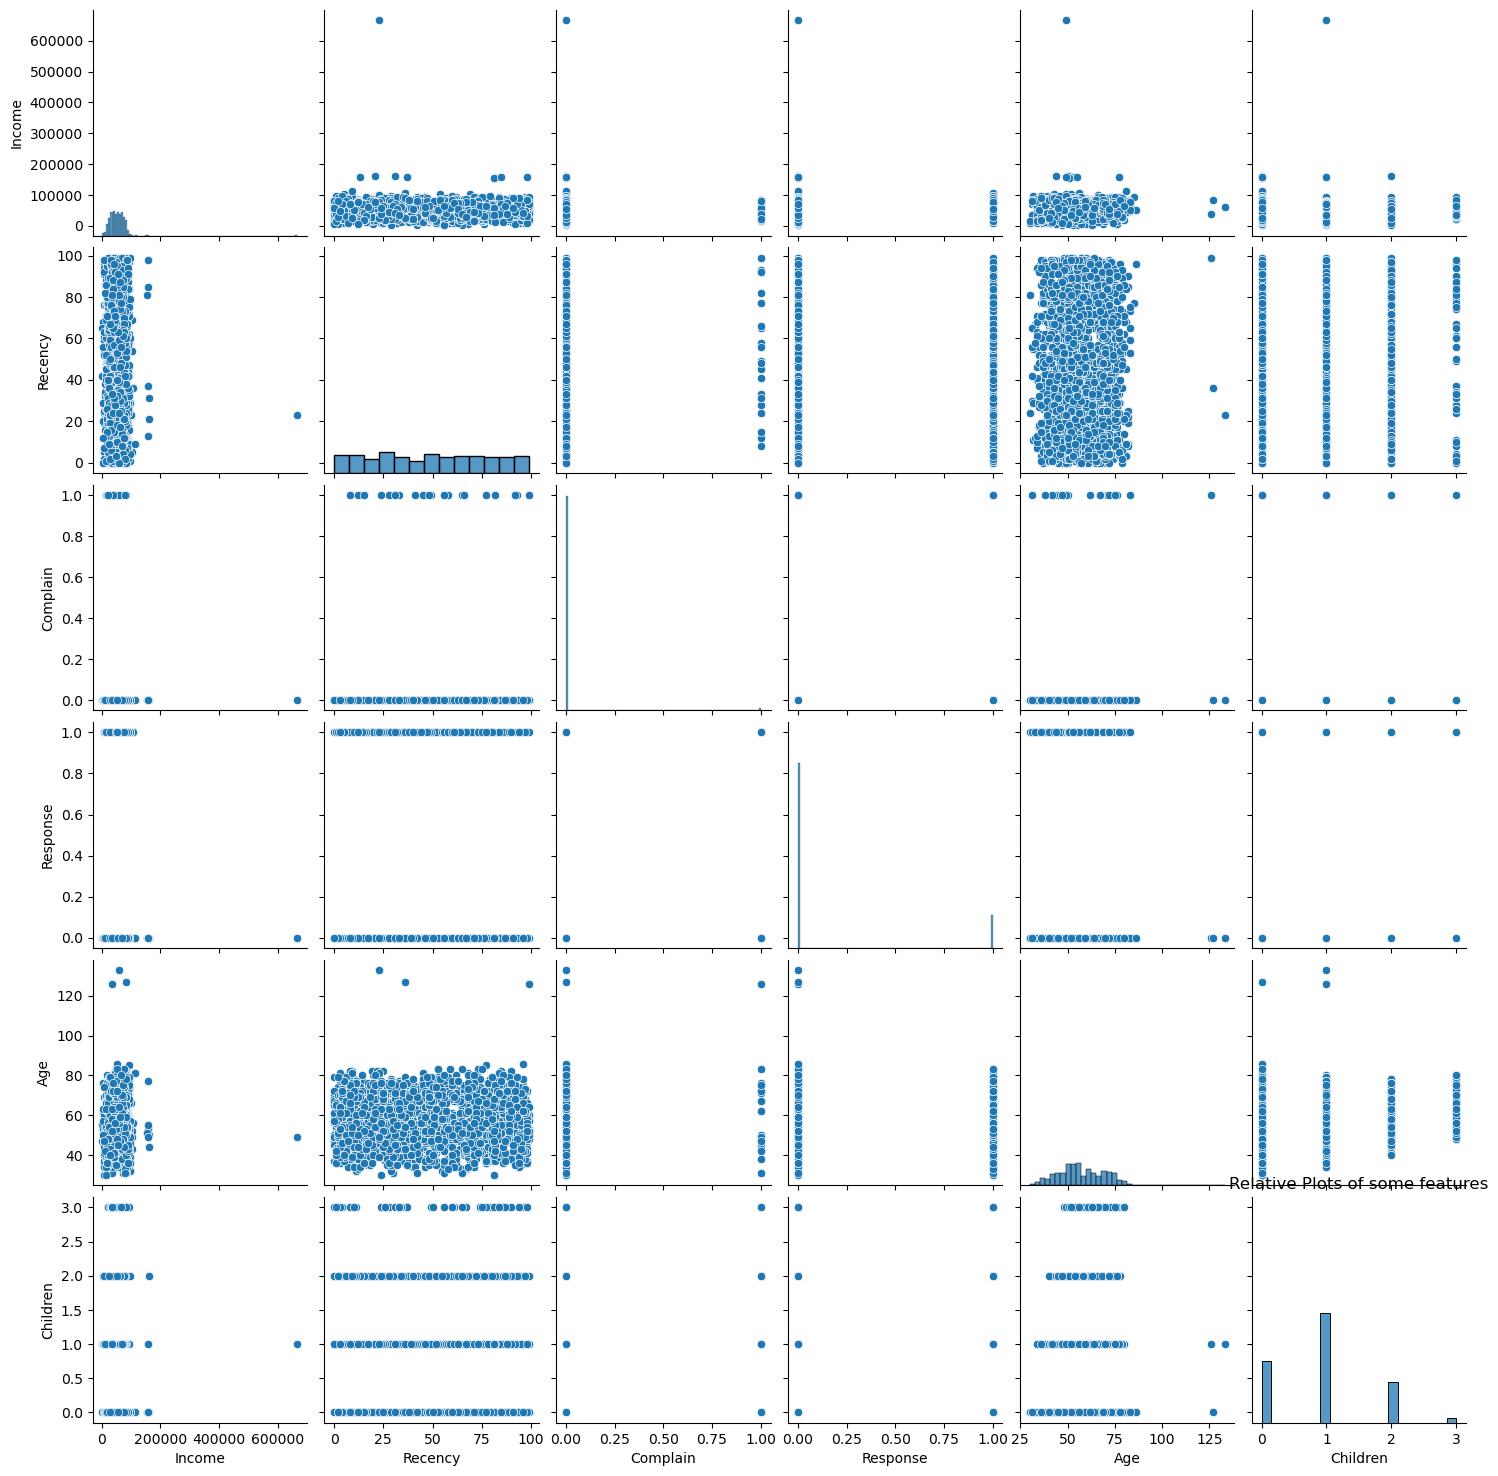

In [30]:
# Detect columns
detect_cols = ['Income', 'Recency', 'Complain', 'Response', 'Age', 'Children']

# Plot Columns
sns.pairplot(dt_cleaned[detect_cols])

plt.title("Relative Plots of some features")
plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Detect_Outliers",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [31]:
# Outliers: 1. Income with more than 600k
#           2. Age of more than 90

In [32]:
print(len(dt_cleaned.loc[dt_cleaned['Income'] > 600000]))

1


In [33]:
print(len(dt_cleaned.loc[dt_cleaned['Age'] >= 90]))

3


In [34]:
# Remove Outliers
print("Dataset with outliers:", len(dt_cleaned))

dt_cleaned = dt_cleaned[ 
                        (dt_cleaned['Income'] <= 600000) &
                        (dt_cleaned['Age'] < 90)
    ]


print("Dataset without outliers:", len(dt_cleaned))

Dataset with outliers: 2240
Dataset without outliers: 2236


In [35]:
print(dt_cleaned['Income'].max())
print(dt_cleaned['Age'].max())

162397.0
86


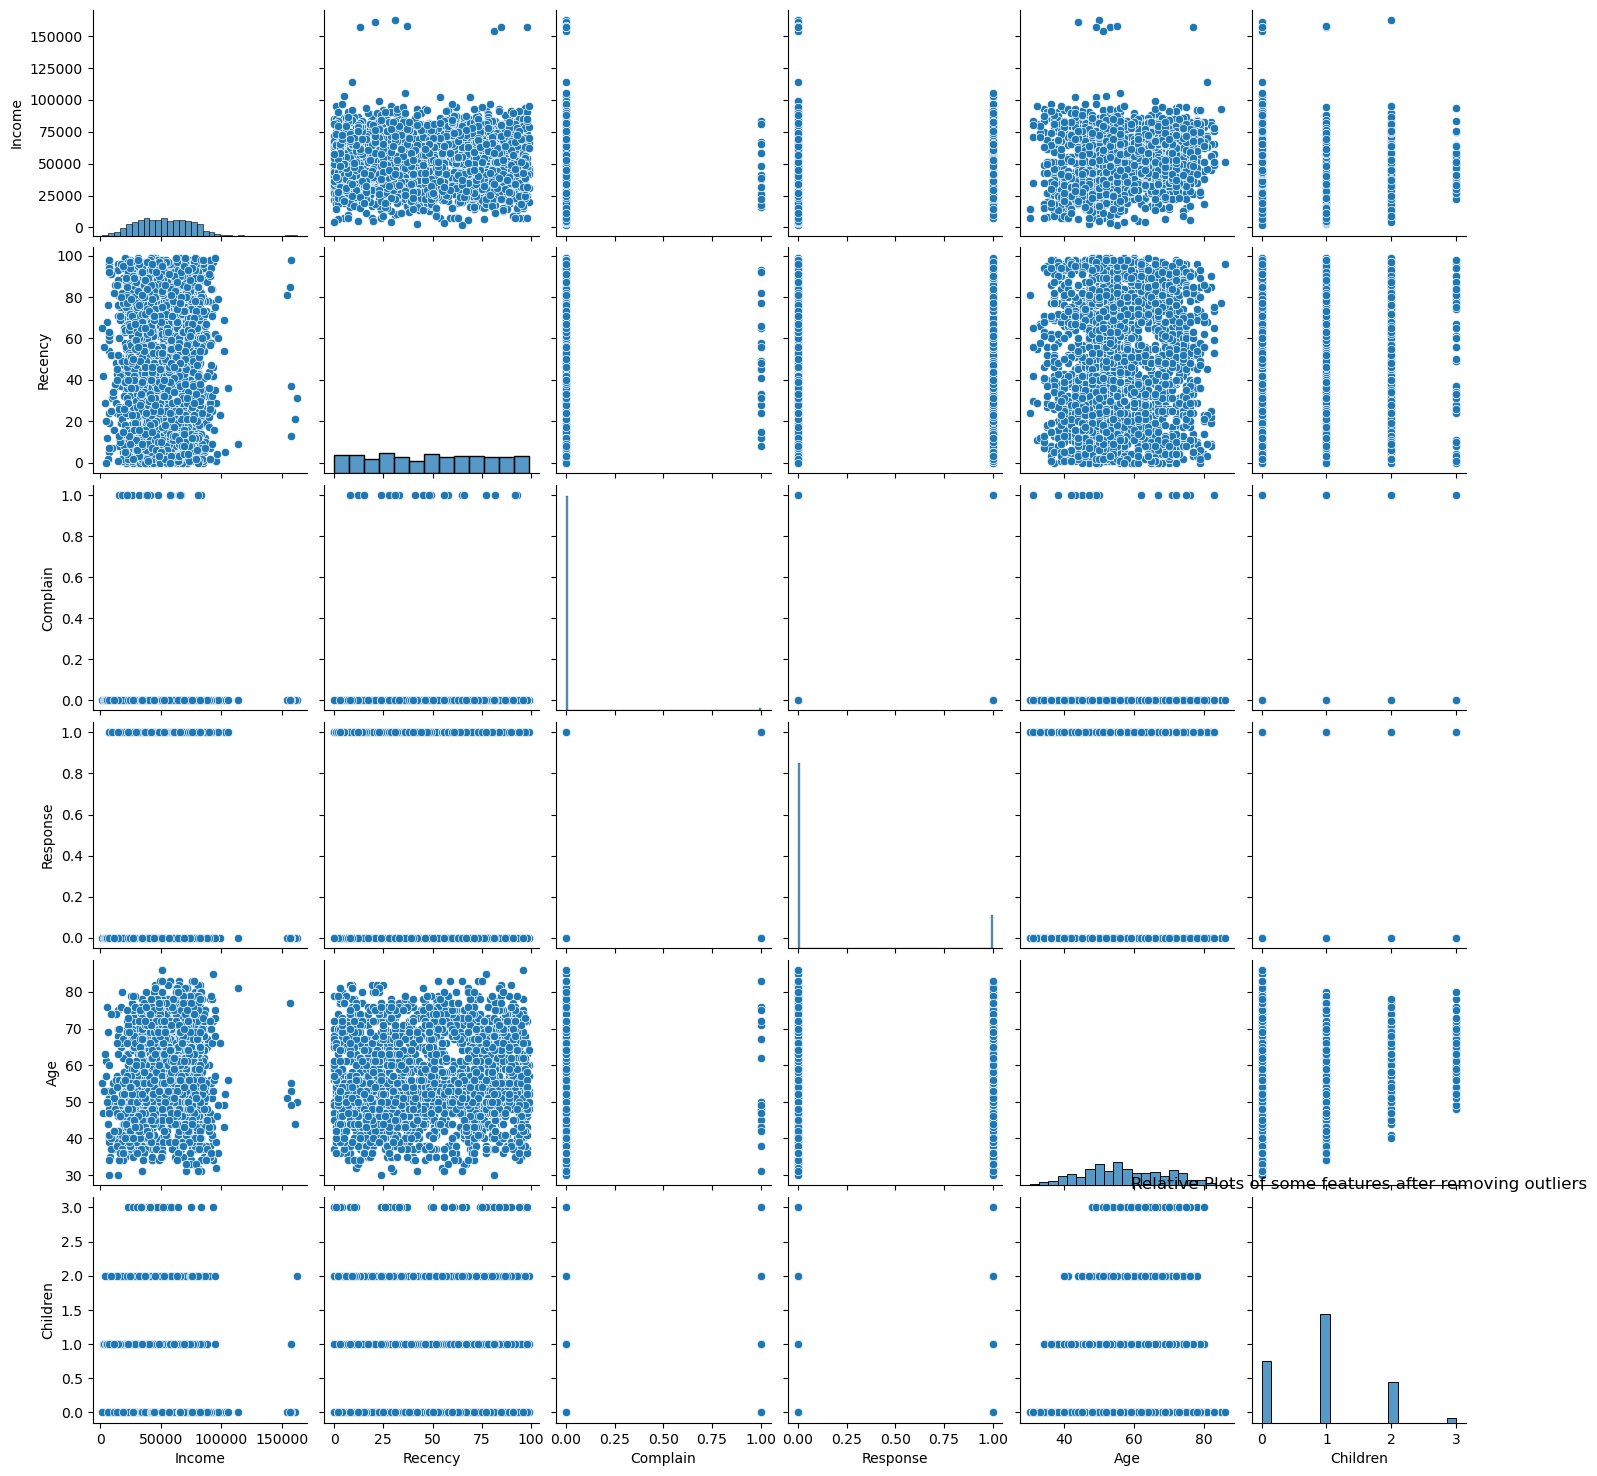

In [36]:
# Detect columns after removing outliers
detect_cols = ['Income', 'Recency', 'Complain', 'Response', 'Age', 'Children']

# Plot Columns
sns.pairplot(dt_cleaned[detect_cols])

plt.title("Relative Plots of some features after removing outliers")
plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Detect_rm-Outliers",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [37]:
dt_cleaned.shape

(2236, 15)

In [38]:
dt.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days',
       'Customer_total_spend', 'Children'],
      dtype='object')

In [39]:
# Find the correlation between numerical features

dt_corr = dt_cleaned.corr(
    numeric_only=True
)

dt_corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


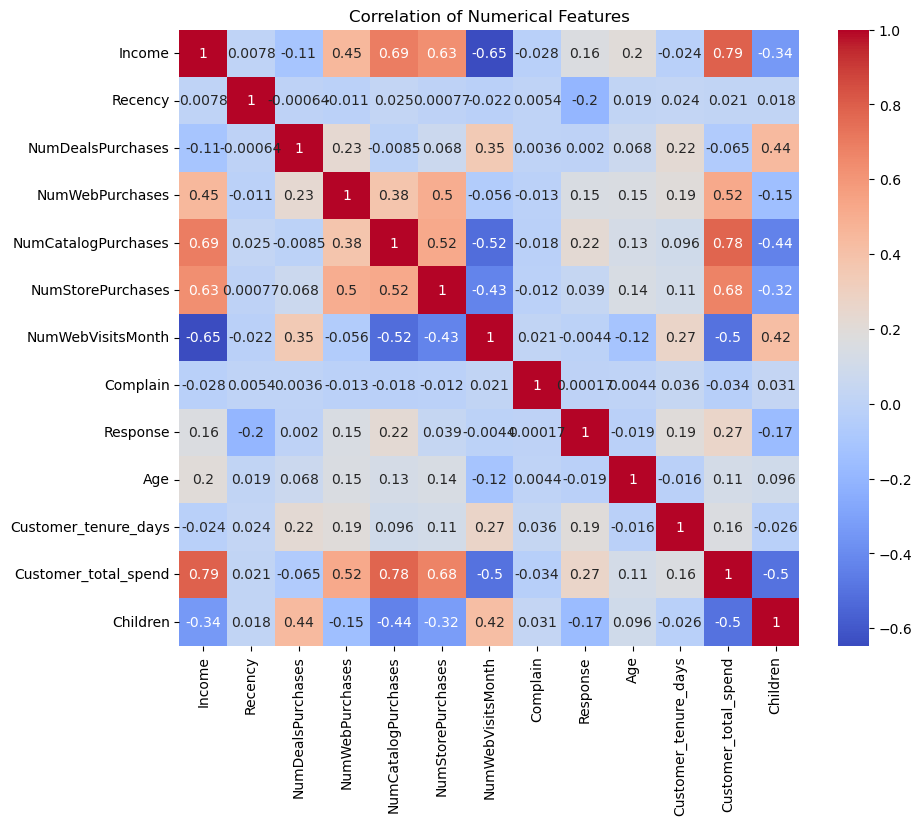

In [40]:
# Plot the Correlation features
plt.figure(figsize=(10, 8))

sns.heatmap(
    dt_corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation of Numerical Features")
plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Numerical_Correlation.png")
plt.show()

In [41]:
# # Relation Insights
# 1. Income increases -> Customer_total_spend increases
# 2. Income increases -> NumStorePurchases increases
# 3. Income increases -> NumWebPurchases decreases
# 4. Income increases -> NumCatalogPurchases increases
# 5. Customer_total_spend increases -> NumStorePurchases increases   # So customers are more offline Store centric
# 6. Customer_total_spend increases -> NumCatalogPurchases increases

# Encode

In [42]:
dt_cleaned.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children
0,Grade,Living_alone,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,Grade,Living_alone,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,Grade,Living_with,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,Grade,Living_with,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,MasterGrade,Living_with,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


In [43]:
# One Hot Encoding on Categorical features(Education & Marital_Status)

dt_cleaned['Education'].value_counts()

Education
Grade          1126
MasterGrade     855
UnderGrade      255
Name: count, dtype: int64

In [44]:
dt_cleaned['Marital_Status'].value_counts()

Marital_Status
Living_with     1442
Living_alone     794
Name: count, dtype: int64

In [45]:
from sklearn.preprocessing import OneHotEncoder

# Create model
ohe = OneHotEncoder()
# List all features
cat_col = ['Education', 'Marital_Status']
# Train model with features
encode_col = ohe.fit_transform(dt_cleaned[cat_col])

In [46]:
# Do not drop the first column after One-Hot-Encode, becuase it only applies on Linear model, not on Clustering model
# Convert that categorical numeric val into indexing as real categorical name of those features
encode_df = pd.DataFrame(encode_col.toarray(), columns=ohe.get_feature_names_out(cat_col), index=dt_cleaned.index)

encode_df.head()

,Education_Grade,Education_MasterGrade,Education_UnderGrade,Marital_Status_Living_alone,Marital_Status_Living_with
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [47]:
# Add this encoding with the actual dataset

dt_cleaned = dt_cleaned.drop(columns=cat_col)

dt_cleaned.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


In [48]:
dt_cleaned.shape

(2236, 13)

In [49]:
encode_df.shape

(2236, 5)

In [50]:
dt_clean_encoded = pd.concat([dt_cleaned, encode_df], axis=1)

dt_clean_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children,Education_Grade,Education_MasterGrade,Education_UnderGrade,Marital_Status_Living_alone,Marital_Status_Living_with
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [51]:
dt_clean_encoded.shape

(2236, 18)

# Scaling 

In [52]:
# Clustering model, so calculated on distance val, so have to scale the dataset
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

dt_clean_encode_scaled = scale.fit_transform(dt_clean_encoded)

In [53]:
dt_clean_encode_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# PCA

In [54]:
dt_clean_encode_scaled.shape

(2236, 18)

In [55]:
# Too many dimensions, so have to reduce that 
from sklearn.decomposition import PCA

# 1st try on 2D
pca = PCA(
    n_components=2,
    random_state=42
)

dt_clean_encode_scale_pca = pca.fit_transform(dt_clean_encode_scaled)

In [56]:
dt_clean_encode_scale_pca

array([[ 2.7087298 ,  2.39869224],
       [-1.76655338,  1.82575242],
       [ 1.81995208, -1.07430148],
       ...,
       [ 1.42793889,  1.81716429],
       [ 1.90073104, -1.4254157 ],
       [-0.96995283, -0.67250249]], shape=(2236, 2))

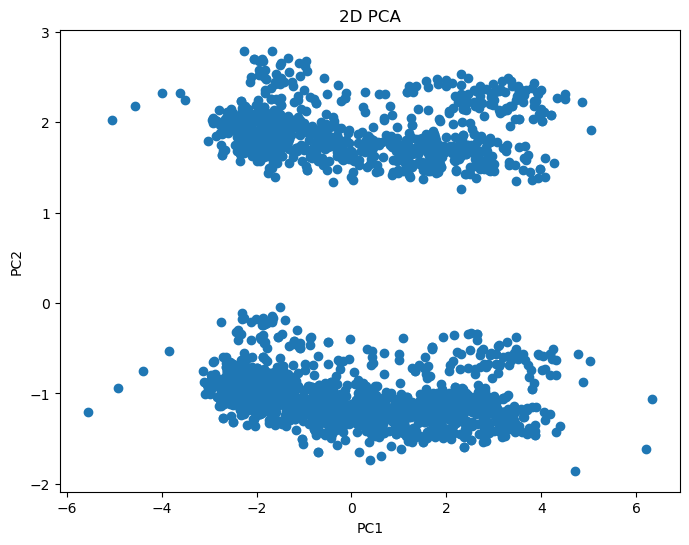

In [57]:
# Vizualize the 2D model 
plt.figure(figsize=(8, 6))

plt.scatter(
    x=dt_clean_encode_scale_pca[:, 0],
    y=dt_clean_encode_scale_pca[:, 1]
)

plt.title("2D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\PCA_2D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [58]:
# Data engaged with PC1 & PC2
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [59]:
# So clearly can see that a huge data has been lost due to 2D model(23 + 11 = 34)%

In [60]:
# 2nd try on 3D 
pca_3D = PCA(
    n_components=3,
    random_state=42
)

dt_clean_encode_scale_pca3D = pca_3D.fit_transform(dt_clean_encode_scaled)

In [61]:
pca_3D.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

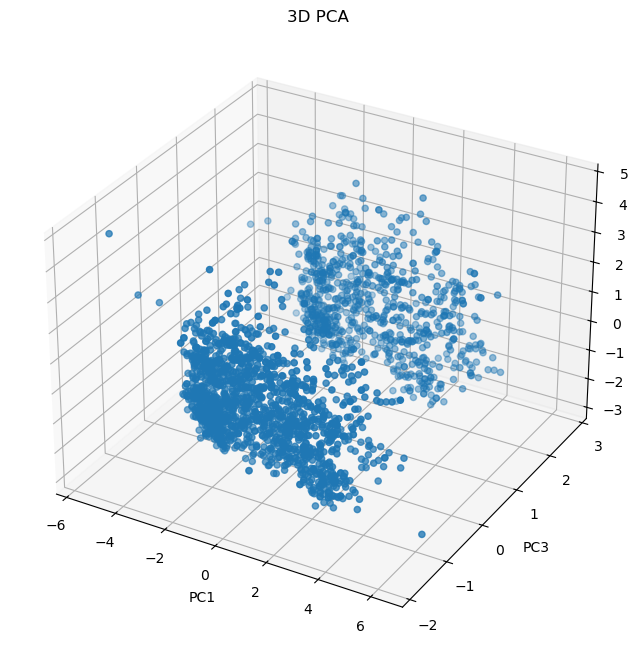

In [62]:
# Vizualize the 3D model 
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    dt_clean_encode_scale_pca3D[:, 0],
    dt_clean_encode_scale_pca3D[:, 1],
    dt_clean_encode_scale_pca3D[:, 2]
)

plt.title("3D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.ylabel("PC3")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\PCA_3D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

# Clustering into Dataset

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [64]:
 # Find Optimal K by WCSS value of Elbow method
wcss = []

for k in range(2, 11):
    # Make the model with multiple k
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    kmeans.fit_predict(dt_clean_encode_scale_pca3D)
    wcss.append(kmeans.inertia_)

print('Within Cluster Sum of Square val are: \n', wcss)

Within Cluster Sum of Square val are: 
 [10760.843401758233, 8830.288717243056, 6650.969417658884, 5006.161168001201, 4396.308699108105, 3857.6330644275654, 3207.057624221644, 3025.223255432568, 2651.442989106131]


In [65]:
knee = KneeLocator(
    range(2, 11), 
    wcss,
    curve="convex",
    direction="decreasing"
)

opt_k = knee.elbow
print("Optimal k val: ", opt_k)

Optimal k val:  5


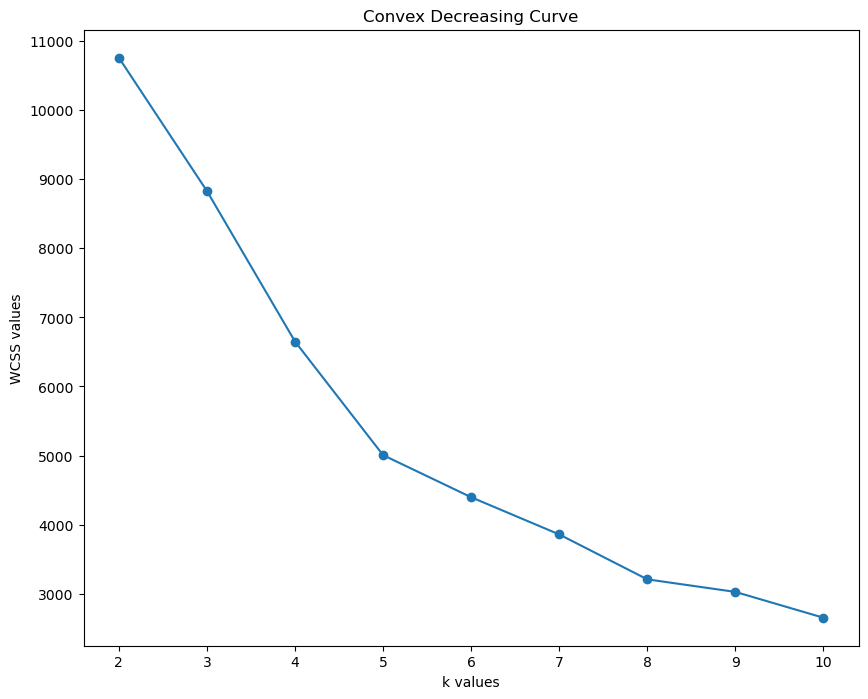

In [66]:
# Plot the Convex Decreasing curve 
plt.figure(figsize=(10, 8))

plt.plot(
    range(2, 11),
    wcss,
    marker='o'
)

plt.title("Convex Decreasing Curve")
plt.xlabel("k values")
plt.ylabel("WCSS values")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Opt_k.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [67]:
# Find optimal k with Silhouette Score
silho_score = []

for k in range(2, 11):
    # Make the model with multiple k
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    kmeans_pred = kmeans.fit_predict(dt_clean_encode_scale_pca3D)
    score = silhouette_score(dt_clean_encode_scale_pca3D, kmeans_pred)
    silho_score.append(score)

print('Silhouette Score val are: \n', silho_score)

Silhouette Score val are: 
 [0.3715793907976446, 0.3076881927474974, 0.3580996159596818, 0.40001521476618634, 0.39929183898565085, 0.4026208740557631, 0.4050858828690464, 0.40118897046525365, 0.40291173364815014]


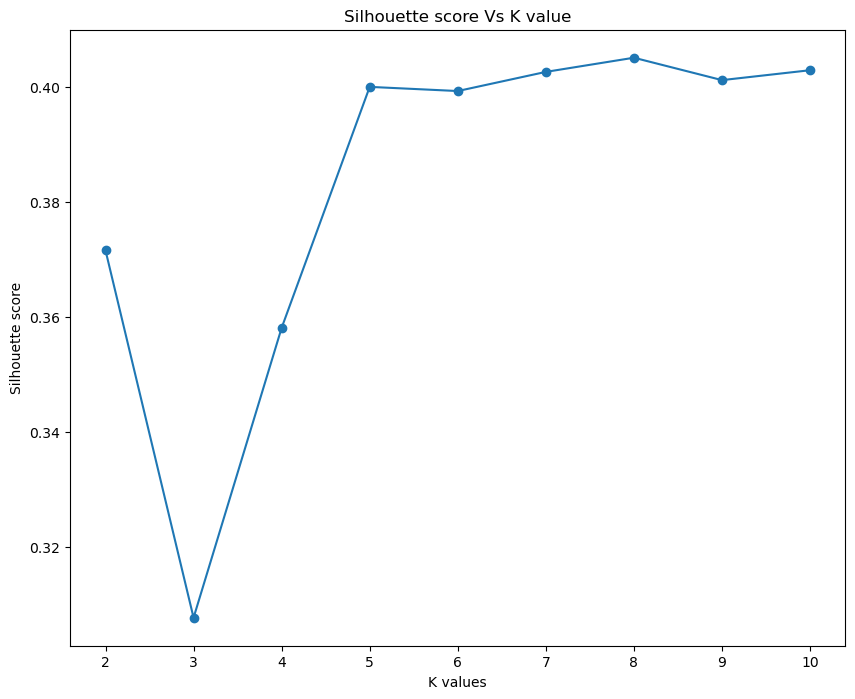

In [68]:
# Plot Silhouette score VS K values
plt.figure(figsize=(10, 8))

plt.plot(
    range(2, 11),
    silho_score,
    marker='o'
)

plt.title("Silhouette score Vs K value")
plt.xlabel("K values")
plt.ylabel("Silhouette score")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Opt_k_Ss.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

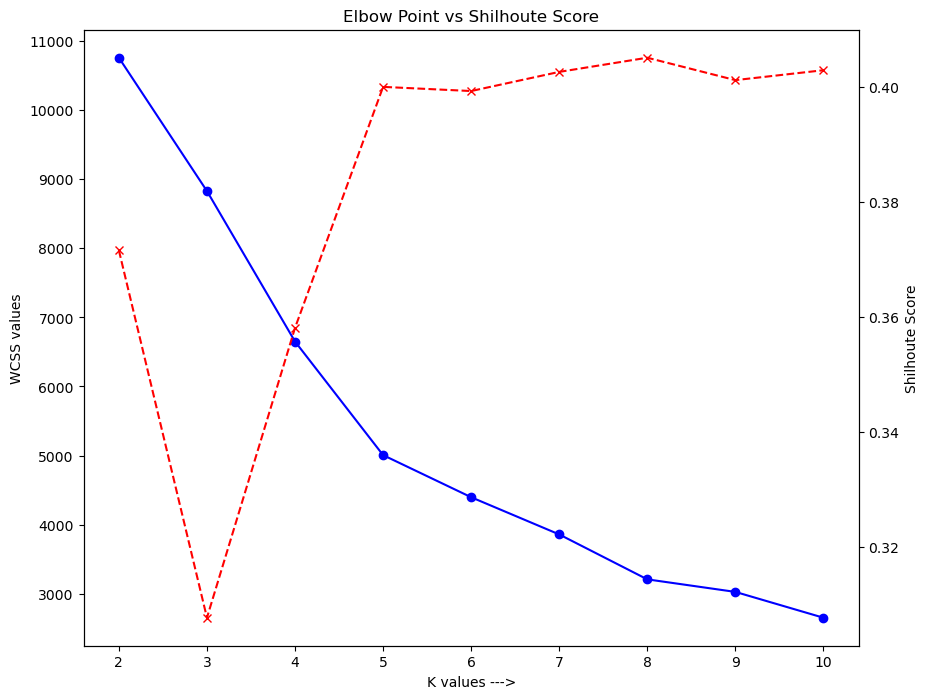

In [69]:
# Cross both plot and See the CrossPoint as Optimal K point
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(10, 8))

ax1.plot(k_range, 
         wcss[: len(k_range)], 
         marker='o', 
         color='blue'
        )
ax1.set_title("Elbow Point vs Shilhoute Score")
ax1.set_xlabel('K values --->')
ax1.set_ylabel('WCSS values')

ax2=ax1.twinx()
ax2.plot(
    k_range,
    silho_score[: len(k_range)],
    marker='x',
    color='red',
    linestyle='--'
)
ax2.set_ylabel('Shilhoute Score')

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Elbow_Shilhoute.png",
           dpi=300,
           bbox_inches="tight"
)
plt.show()

In [70]:
# Train K-means clustering model with optimal k value
kCluster_model = KMeans(
    n_clusters=opt_k,
    init='k-means++',
    random_state=42,
    algorithm='lloyd'
)

label = kCluster_model.fit_predict(dt_clean_encode_scale_pca3D)

In [71]:
label

array([2, 4, 1, ..., 2, 1, 3], shape=(2236,), dtype=int32)

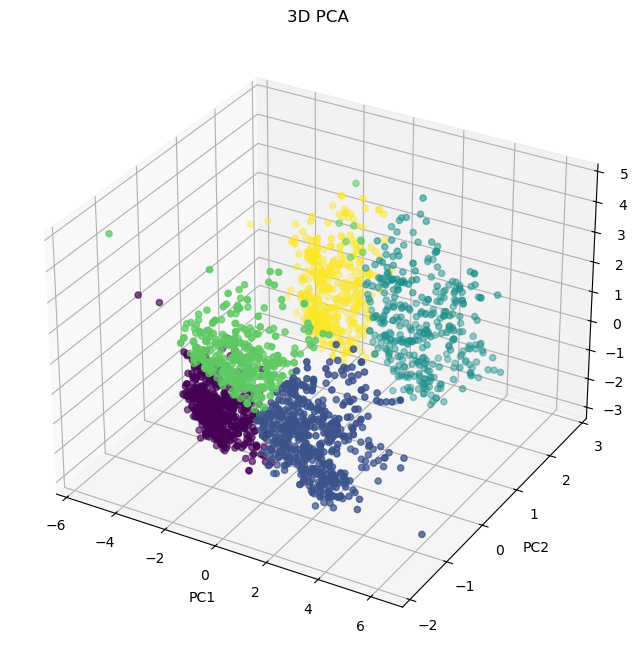

In [72]:
# Plot the Dataset and Visualise the clustering parts
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    dt_clean_encode_scale_pca3D[:, 0],
    dt_clean_encode_scale_pca3D[:, 1],
    dt_clean_encode_scale_pca3D[:, 2],
    c=label
)

plt.title("3D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\kCluster_3D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

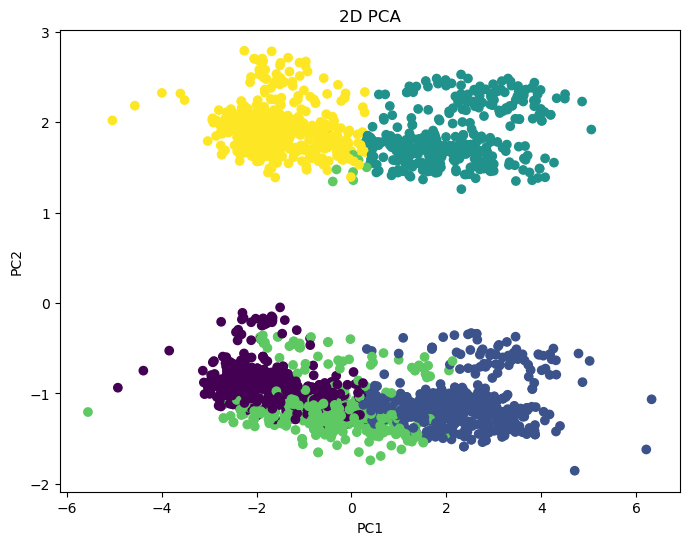

In [73]:
# Vizualize the 2D model 
plt.figure(figsize=(8, 6))

plt.scatter(
    x=dt_clean_encode_scale_pca[:, 0],
    y=dt_clean_encode_scale_pca[:, 1],
    c=label
)

plt.title("2D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\kCluster_2D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [74]:
# Clustering by Agglomerative Hierarchical model(Bottom-Up)
from sklearn.cluster import AgglomerativeClustering

agglo_model = AgglomerativeClustering(
    n_clusters=opt_k,
    linkage='ward',
    metric='euclidean'
)

label2 = agglo_model.fit_predict(dt_clean_encode_scale_pca3D)

In [75]:
label2

array([3, 2, 0, ..., 3, 0, 4], shape=(2236,))

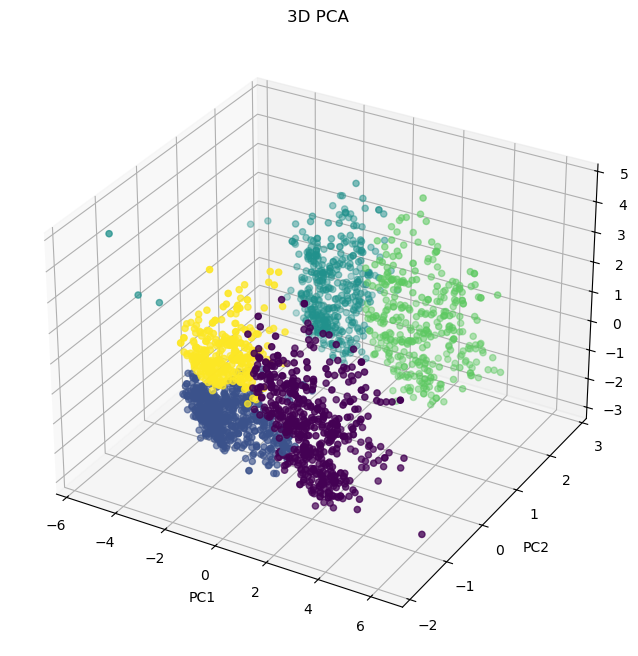

In [76]:
# Plot the Dataset and Visualise the clustering parts
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    dt_clean_encode_scale_pca3D[:, 0],
    dt_clean_encode_scale_pca3D[:, 1],
    dt_clean_encode_scale_pca3D[:, 2],
    c=label2
)

plt.title("3D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\agglo_Cluster_3D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

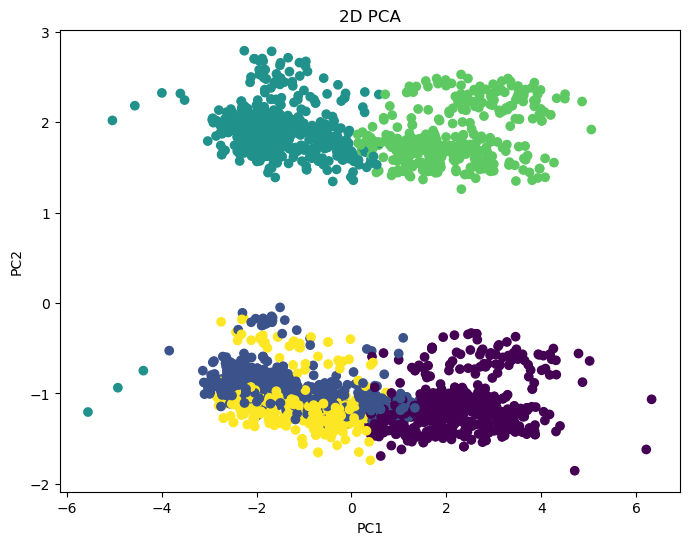

In [77]:
# Vizualize the 2D model 
plt.figure(figsize=(8, 6))

plt.scatter(
    x=dt_clean_encode_scale_pca[:, 0],
    y=dt_clean_encode_scale_pca[:, 1],
    c=label2
)

plt.title("2D PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\agglo_Cluster_2D.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

# # Characterisation of every cluster

In [78]:
# We are add this label dataset as Clustering feature in the actual table, 
# because want groupby based on this cluster and Characterization them .
# Now Scaled and PCA data dont want, because it was needed for clustering model.
# So add Clustering on 'dt_clean_encoded' dataset

In [79]:
dt_clean_encoded.shape

(2236, 18)

In [80]:
type(dt_clean_encoded)

pandas.core.frame.DataFrame

In [81]:
label.shape

(2236,)

In [82]:
type(label)

numpy.ndarray

In [83]:
# Add Cluster dataset in main dataset as a Feature
dt_clean_encoded["Clusters"] = label

In [84]:
dt_clean_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children,Education_Grade,Education_MasterGrade,Education_UnderGrade,Marital_Status_Living_alone,Marital_Status_Living_with,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,4
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,3


In [85]:
print(np.unique(dt_clean_encoded["Clusters"]))

[0 1 2 3 4]


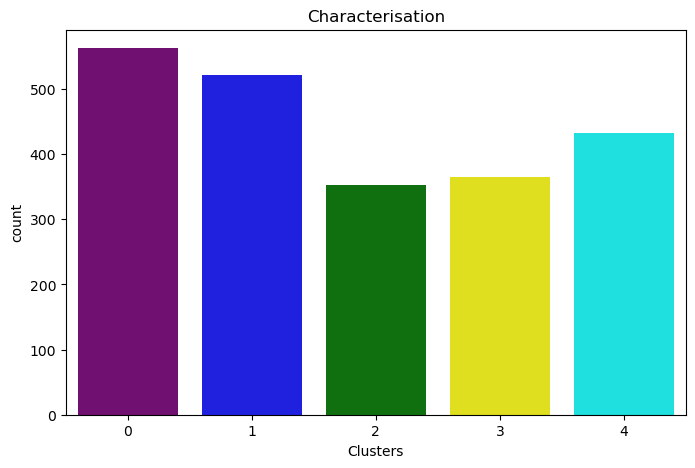

In [86]:
# Took 5 diff color and initialised them with 5 diff Clusters

cluster_color = ["purple", "blue", "green", "yellow", "cyan"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
        x=dt_clean_encoded["Clusters"],
        palette=cluster_color,
        hue=dt_clean_encoded["Clusters"]
    )

ax.legend_.remove()   
plt.title("Characterisation")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Characterisation.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [87]:
dt_clean_encoded.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days',
       'Customer_total_spend', 'Children', 'Education_Grade',
       'Education_MasterGrade', 'Education_UnderGrade',
       'Marital_Status_Living_alone', 'Marital_Status_Living_with',
       'Clusters'],
      dtype='object')

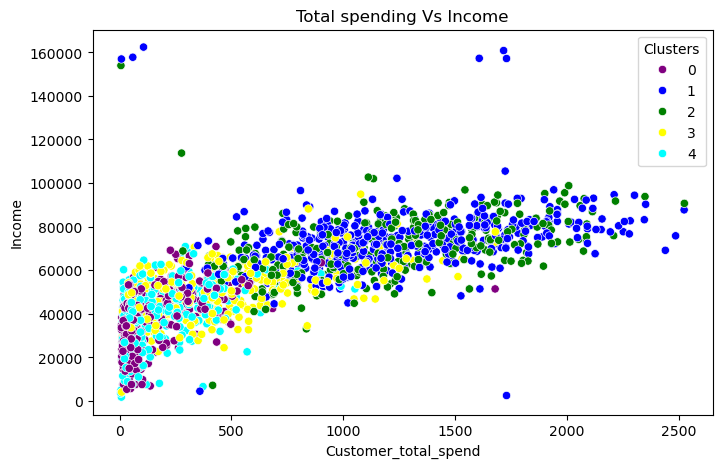

In [88]:
# Take two correlated features and plot based on the Clustering dataset
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=dt_clean_encoded['Customer_total_spend'], 
    y=dt_clean_encoded['Income'], 
    hue=dt_clean_encoded['Clusters'],
    palette=cluster_color
)

plt.title("Total spending Vs Income")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Income_Spending.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [89]:
# # Can categories into 5 catagories:
# 1. purple = Income & Spending is less
# 2. blue = Income & Spending are very high
# 3. green = Income high & Spending is moderate
# 4. yellow = Income & Spending are moderate
# 5. cyan = Income & Spending is less

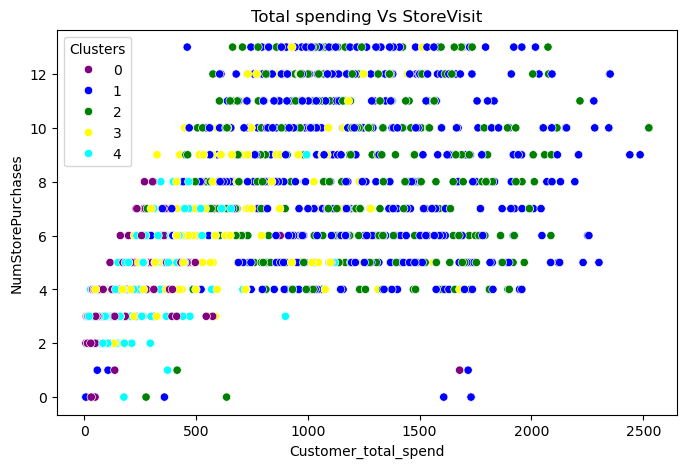

In [90]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=dt_clean_encoded['Customer_total_spend'], 
    y=dt_clean_encoded['NumStorePurchases'], 
    hue=dt_clean_encoded['Clusters'],
    palette=cluster_color
)

plt.title("Total spending Vs StoreVisit")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Store_Spending.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

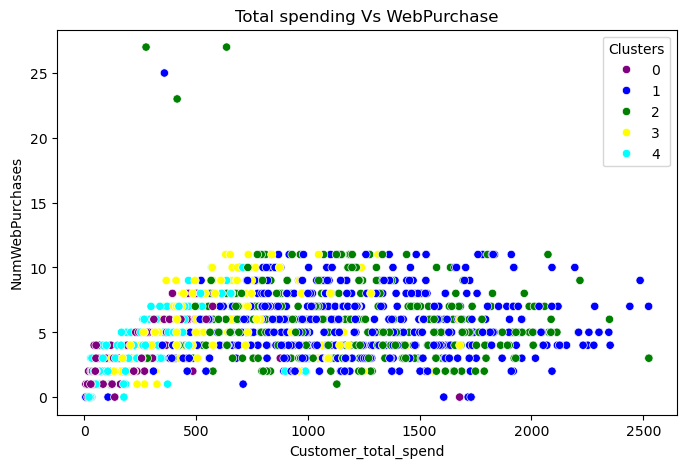

In [91]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=dt_clean_encoded['Customer_total_spend'], 
    y=dt_clean_encoded['NumWebPurchases'], 
    hue=dt_clean_encoded['Clusters'],
    palette=cluster_color
)

plt.title("Total spending Vs WebPurchase")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Web_Spending.png",
           dpi=300,
           bbox_inches="tight"
)

plt.show()

In [92]:
# So, Spending is Higher in Store(Offline) than Website(online)

# Clustering Summery

In [93]:
# Calculate every features mean val based on Clustering dataset

cluster_summery = dt_clean_encoded.groupby('Clusters').mean()

cluster_summery

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Customer_total_spend,Children,Education_Grade,Education_MasterGrade,Education_UnderGrade,Marital_Status_Living_alone,Marital_Status_Living_with
Clusters,,,,,,,,,,,,,,,,,,
0,34209.454707,50.614565,1.987567,2.261101,0.548845,3.385435,6.495560,0.014210,0.047957,53.149201,328.257549,119.182948,1.168739,0.658970,0.136767,0.204263,0.000000,1.000000
1,72833.211686,48.538314,1.819923,5.655172,5.444444,8.611111,3.383142,0.009579,0.147510,58.856322,354.191571,1229.024904,0.465517,0.601533,0.321839,0.076628,0.000000,1.000000
2,70701.158640,50.524079,1.872521,5.804533,5.022663,8.436261,3.719547,0.005666,0.322946,58.929178,373.869688,1190.226629,0.461756,0.535411,0.399433,0.065156,1.000000,0.000000
3,49157.324658,47.539726,3.819178,4.690411,1.882192,5.561644,6.336986,0.000000,0.150685,60.882192,390.147945,433.487671,1.413699,0.090411,0.863014,0.046575,0.021918,0.978082
4,36922.062356,48.046189,2.487298,2.665127,0.794457,3.579677,6.568129,0.011547,0.140878,55.450346,339.399538,156.956120,1.260970,0.505774,0.355658,0.138568,1.000000,0.000000


In [94]:
type(cluster_summery)

pandas.core.frame.DataFrame

In [96]:
cluster_summery.to_csv(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Clustering_Summery.csv", index=False)

# Heatmap on Cluster Rank Summary

In [100]:
cluster_rank_df = pd.read_csv('cluster_rank_summary.csv')

In [101]:
rank_map = {
    "Highest": 5,
    "High": 4,
    "Moderate": 3,
    "Low": 2,
    "Lowest": 1
}

rank_df = cluster_rank_df.replace(rank_map)

C:\Users\91628\AppData\Local\Temp\ipykernel_15696\2598937315.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rank_df = cluster_rank_df.replace(rank_map)


In [103]:
rank_df = rank_df.set_index("Cluster")

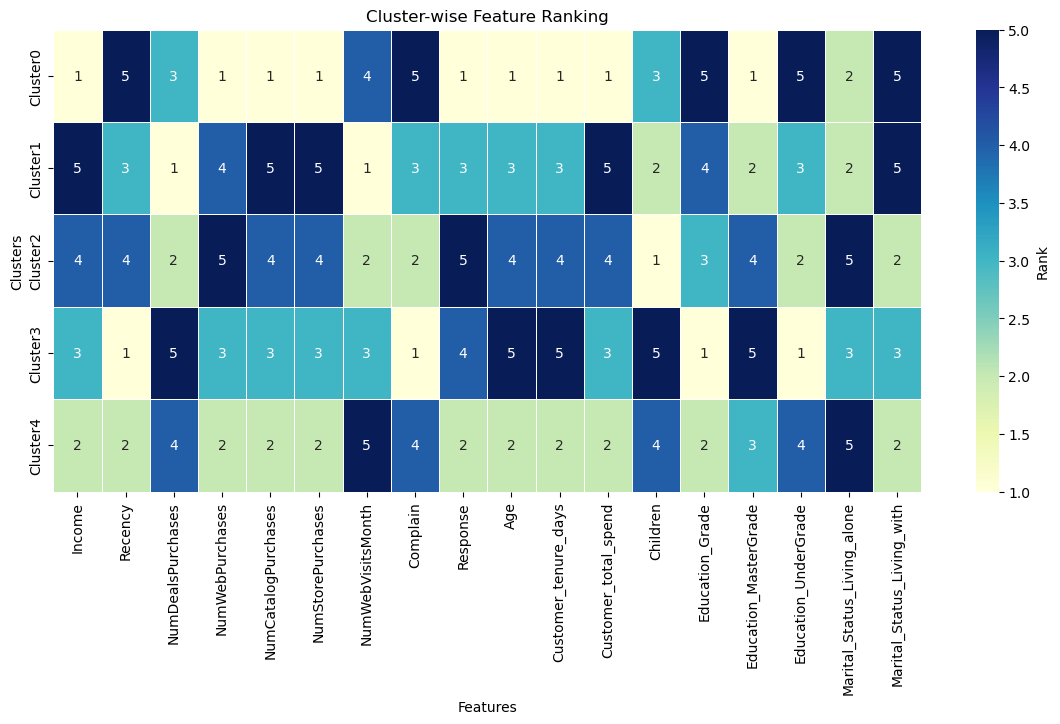

In [110]:
plt.figure(figsize=(14,6))

sns.heatmap(
    rank_df,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label":"Rank"}
)

plt.title("Cluster-wise Feature Ranking")
plt.xlabel("Features")
plt.ylabel("Clusters")

plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Heatmap_Cluster_Rank_Sum.png",
           dpi=300,
           bbox_inches="tight"
)
plt.show()

# Radar (Spider) Chart 

In [108]:
radar_df = rank_df.drop(
    columns=[
        "Education_Grade",
        "Education_MasterGrade",
        "Education_UnderGrade",
        "Complain",
        "Response"
    ]
)

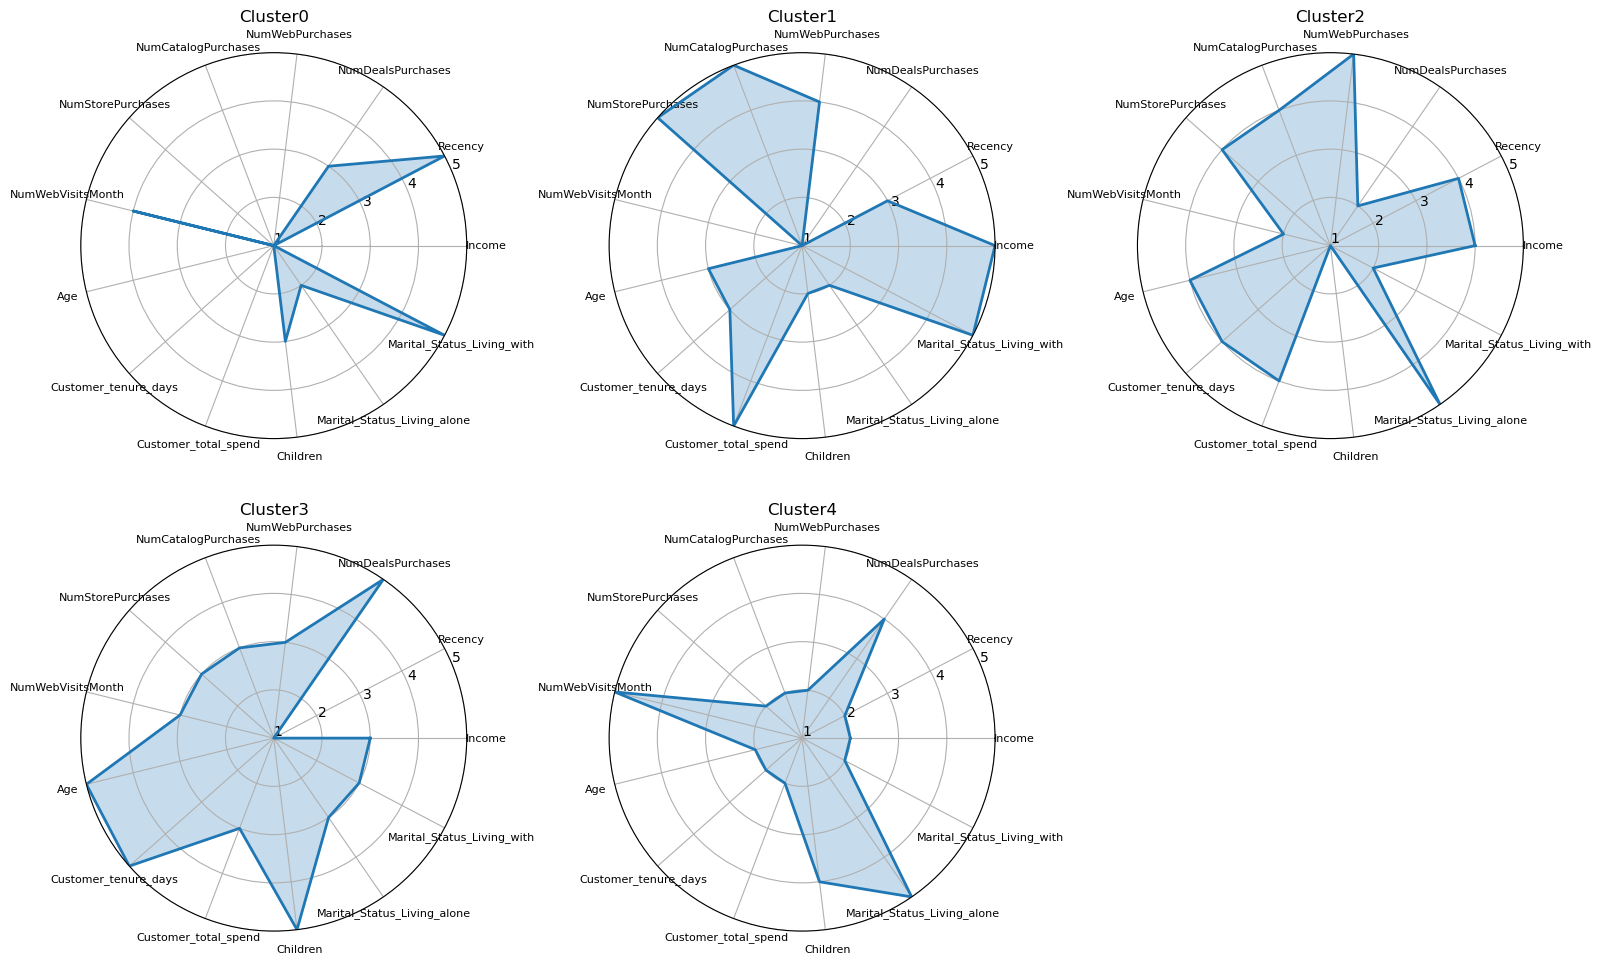

In [111]:
categories = radar_df.columns.tolist()
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16,10),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for i, cluster in enumerate(radar_df.index):
    values = radar_df.loc[cluster].tolist()
    values += values[:1]

    ax = axes[i]
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_yticks([1,2,3,4,5])
    ax.set_ylim(1,5)
    ax.set_title(cluster)

# Remove the unused 6th subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig(r"C:\Users\91628\IdeaProjects\Apna_cllg_JupyterLab\ML Projects\3. SmartCart Clustering System\Spider_Cluster_Rank_Sum.png",
           dpi=300,
           bbox_inches="tight"
)
plt.show()